# FaceFit Barber — Data Science Pipeline
## Minggu 1: Data Gathering & Assessing

**Tim:** CC26-PSU304  
**Dikerjakan oleh:** Diwan Ramadhani Dwi Putra (CDCC119D6Y1045)  
**Path:** Data Scientist  
**Last Modified:** 26 April 2026

---

### Tujuan Notebook Ini
Notebook ini mencakup tahap awal pipeline Data Science untuk proyek FaceFit Barber, yaitu:
1. **Gathering** — Download dan muat dataset dari Kaggle
2. **Assessing** — Evaluasi kondisi awal tiap dataset sebelum proses cleaning

Dataset yang digunakan pada notebook ini:
- **UTKFace** — Dataset wajah in-the-wild, difilter untuk ras Asian (race=2)
- **FairFace** — Dataset wajah multi-ras, difilter untuk East Asian & Southeast Asian
- **Men Face Shape** — Dataset wajah pria dengan label bentuk wajah

> **Notes:** Seluruh proses pembersihan data dilakukan secara aktual pada notebook ini. Tidak ada dataset yang digunakan langsung tanpa preprocessing.

---
## 0. Setup Environment

In [35]:
# Install library yang dibutuhkan
!pip install kaggle opencv-python-headless Pillow pandas numpy matplotlib seaborn -q

In [36]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style visualisasi
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('✅ Semua library berhasil diimport')

✅ Semua library berhasil diimport


In [37]:
# Setup Kaggle API
os.environ['KAGGLE_TOKEN'] = "KGAT_956fae652fabb2635ea2977b19c00896"

!pip install kaggle -q
print("✅ Kaggle API siap")

✅ Kaggle API siap


In [38]:
# Buat struktur folder kerja
BASE_DIR = '/content/facefit_data'
DIRS = [
    f'{BASE_DIR}/raw/utkface',
    f'{BASE_DIR}/raw/fairface',
    f'{BASE_DIR}/raw/men_face_shape',
    f'{BASE_DIR}/filtered/asian_utkface',
    f'{BASE_DIR}/filtered/asian_fairface',
    f'{BASE_DIR}/filtered/men_face_shape',
    f'{BASE_DIR}/reports',
]

for d in DIRS:
    os.makedirs(d, exist_ok=True)

print('✅ Struktur folder berhasil dibuat:')
for d in DIRS:
    print(f'   {d}')

✅ Struktur folder berhasil dibuat:
   /content/facefit_data/raw/utkface
   /content/facefit_data/raw/fairface
   /content/facefit_data/raw/men_face_shape
   /content/facefit_data/filtered/asian_utkface
   /content/facefit_data/filtered/asian_fairface
   /content/facefit_data/filtered/men_face_shape
   /content/facefit_data/reports


---
## 1. Gathering Data

Pada tahap ini, kita mengunduh 3 dataset dari Kaggle menggunakan Kaggle API.

### 1.1 Download UTKFace

In [39]:
# Download UTKFace dataset
print('Downloading UTKFace...')
!kaggle datasets download -d jangedoo/utkface-new -p {BASE_DIR}/raw/utkface --unzip -q
print('✅ UTKFace berhasil didownload')

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
✅ UTKFace berhasil didownload


In [40]:
# Cek struktur folder UTKFace setelah download
!find {BASE_DIR}/raw/utkface -type d | head -20
print('---')
!find {BASE_DIR}/raw/utkface -name '*.jpg' | wc -l

/content/facefit_data/raw/utkface
/content/facefit_data/raw/utkface/utkface_aligned_cropped
/content/facefit_data/raw/utkface/utkface_aligned_cropped/UTKFace
/content/facefit_data/raw/utkface/utkface_aligned_cropped/crop_part1
/content/facefit_data/raw/utkface/UTKFace
/content/facefit_data/raw/utkface/crop_part1
---
66976


In [41]:
# Cari path folder yang berisi file jpg UTKFace
utkface_images = list(Path(f'{BASE_DIR}/raw/utkface').rglob('*.jpg'))
print(f'Total file gambar UTKFace: {len(utkface_images)}')
print(f'Contoh nama file: {utkface_images[0].name}')

Total file gambar UTKFace: 66976
Contoh nama file: 55_0_1_20170117170627262.jpg.chip.jpg


### 1.2 Download FairFace

In [42]:
# Download FairFace dataset
print('Downloading FairFace...')
!kaggle datasets download -d mehmoodsheikh/fairface-dataset -p {BASE_DIR}/raw/fairface --unzip -q
print('✅ FairFace berhasil didownload')

Dataset URL: https://www.kaggle.com/datasets/mehmoodsheikh/fairface-dataset
License(s): MIT
✅ FairFace berhasil didownload


In [43]:
# Cek struktur folder FairFace
!find {BASE_DIR}/raw/fairface -type f | head -20
print('---')
# Cek apakah ada file CSV label
!find {BASE_DIR}/raw/fairface -name '*.csv'

/content/facefit_data/raw/fairface/FairFace/fairface_label_val.csv
/content/facefit_data/raw/fairface/FairFace/fairface_label_train.csv
/content/facefit_data/raw/fairface/FairFace/train/1.jpg
/content/facefit_data/raw/fairface/FairFace/train/10.jpg
/content/facefit_data/raw/fairface/FairFace/train/100.jpg
/content/facefit_data/raw/fairface/FairFace/train/1000.jpg
/content/facefit_data/raw/fairface/FairFace/train/10000.jpg
/content/facefit_data/raw/fairface/FairFace/train/10001.jpg
/content/facefit_data/raw/fairface/FairFace/train/10002.jpg
/content/facefit_data/raw/fairface/FairFace/train/10003.jpg
/content/facefit_data/raw/fairface/FairFace/train/10004.jpg
/content/facefit_data/raw/fairface/FairFace/train/10005.jpg
/content/facefit_data/raw/fairface/FairFace/train/10006.jpg
/content/facefit_data/raw/fairface/FairFace/train/10007.jpg
/content/facefit_data/raw/fairface/FairFace/train/10008.jpg
/content/facefit_data/raw/fairface/FairFace/train/10009.jpg
/content/facefit_data/raw/fairface

In [44]:
# Load dan gabungkan CSV label FairFace (train + val)
fairface_csv_files = list(Path(f'{BASE_DIR}/raw/fairface').rglob('*.csv'))
print(f'File CSV ditemukan: {fairface_csv_files}')

dfs = []
for csv_path in fairface_csv_files:
    df_temp = pd.read_csv(csv_path)
    # Tambah info split (train/val) dari nama file
    split_name = "train" if "train" in csv_path.name else "val"
    df_temp["split"] = split_name
    dfs.append(df_temp)

df_fairface_label = pd.concat(dfs, ignore_index=True)
print(f'Total setelah digabung: {df_fairface_label.shape}')
print(f'Kolom: {df_fairface_label.columns.tolist()}')
print(f'Distribusi split:')
print(df_fairface_label["split"].value_counts())
display(df_fairface_label.head())

File CSV ditemukan: [PosixPath('/content/facefit_data/raw/fairface/FairFace/fairface_label_val.csv'), PosixPath('/content/facefit_data/raw/fairface/FairFace/fairface_label_train.csv')]
Total setelah digabung: (97698, 6)
Kolom: ['file', 'age', 'gender', 'race', 'service_test', 'split']
Distribusi split:
split
train    86744
val      10954
Name: count, dtype: int64


,file,age,gender,race,service_test,split
0,val/1.jpg,3-9,Male,East Asian,False,val
1,val/2.jpg,50-59,Female,East Asian,True,val
2,val/3.jpg,30-39,Male,White,True,val
3,val/4.jpg,20-29,Female,Latino_Hispanic,True,val
4,val/5.jpg,20-29,Male,Southeast Asian,False,val


### 1.3 Download Men Face Shape

In [45]:
# Download Men Face Shape dataset
print('Downloading Men Face Shape...')
!kaggle datasets download -d hanakb/men-face-shape -p {BASE_DIR}/raw/men_face_shape --unzip -q
print('✅ Men Face Shape berhasil didownload')

Dataset URL: https://www.kaggle.com/datasets/hanakb/men-face-shape
License(s): unknown
✅ Men Face Shape berhasil didownload


In [46]:
# Cek struktur folder Men Face Shape
!find {BASE_DIR}/raw/men_face_shape -type d
print('---')
!find {BASE_DIR}/raw/men_face_shape -name '*.jpg' | wc -l

/content/facefit_data/raw/men_face_shape
/content/facefit_data/raw/men_face_shape/men
/content/facefit_data/raw/men_face_shape/men/testing_set
/content/facefit_data/raw/men_face_shape/men/testing_set/ovale
/content/facefit_data/raw/men_face_shape/men/testing_set/rectangular
/content/facefit_data/raw/men_face_shape/men/testing_set/square
/content/facefit_data/raw/men_face_shape/men/testing_set/round
/content/facefit_data/raw/men_face_shape/men/training_set
/content/facefit_data/raw/men_face_shape/men/training_set/ovale
/content/facefit_data/raw/men_face_shape/men/training_set/rectangular
/content/facefit_data/raw/men_face_shape/men/training_set/square
/content/facefit_data/raw/men_face_shape/men/training_set/round
---
1309


---
## 2. Assessing Data

Sebelum melakukan cleaning, kita perlu mengevaluasi kondisi awal setiap dataset untuk mengetahui:
- Jumlah total gambar
- Distribusi label/ras
- Ukuran gambar
- Kondisi kualitas gambar (blur, corrupt, oklusi)
- Potensi masalah yang perlu dibersihkan

### 2.1 Assessing UTKFace

Nama file UTKFace mengikuti format: `[age]_[gender]_[race]_[datetime].jpg`  
Race encoding: 0=White, 1=Black, **2=Asian**, 3=Indian, 4=Others

In [47]:
# Parse metadata dari nama file UTKFace
utk_records = []
utk_skip = 0

for img_path in utkface_images:
    filename = img_path.stem  # tanpa ekstensi
    parts = filename.split('_')

    # Skip file dengan format nama tidak valid
    if len(parts) < 3:
        utk_skip += 1
        continue

    try:
        age  = int(parts[0])
        gender = int(parts[1])
        race = int(parts[2])
        utk_records.append({
            'filepath': str(img_path),
            'filename': img_path.name,
            'age': age,
            'gender': gender,
            'race': race
        })
    except:
        utk_skip += 1

df_utk = pd.DataFrame(utk_records)
print(f'Total file berhasil diparsing : {len(df_utk)}')
print(f'File skip (format tidak valid): {utk_skip}')
display(df_utk.head())

Total file berhasil diparsing : 66966
File skip (format tidak valid): 10


,filepath,filename,age,gender,race
0,/content/facefit_data/raw/utkface/UTKFace/55_0...,55_0_1_20170117170627262.jpg.chip.jpg,55,0,1
1,/content/facefit_data/raw/utkface/UTKFace/8_1_...,8_1_0_20170109202257880.jpg.chip.jpg,8,1,0
2,/content/facefit_data/raw/utkface/UTKFace/23_0...,23_0_3_20170119164007795.jpg.chip.jpg,23,0,3
3,/content/facefit_data/raw/utkface/UTKFace/65_0...,65_0_0_20170111204905982.jpg.chip.jpg,65,0,0
4,/content/facefit_data/raw/utkface/UTKFace/26_1...,26_1_3_20170119155612442.jpg.chip.jpg,26,1,3


Distribusi Ras di UTKFace:
race_label
White     30686
Indian    10854
Asian      9974
Black      9862
Others     5590
Name: count, dtype: int64

Jumlah gambar Asian (race=2): 9974


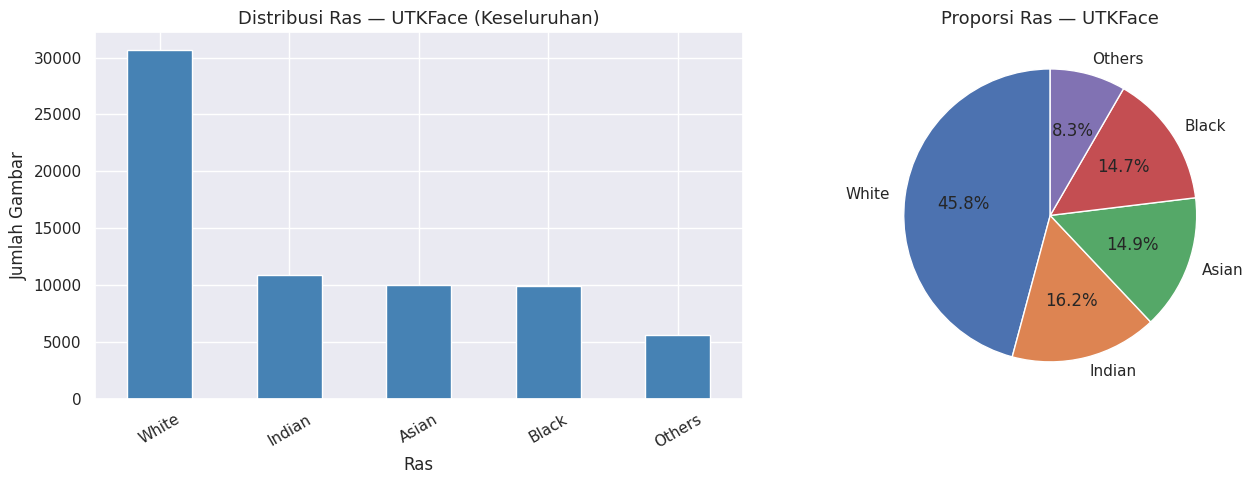


📊 Visualisasi disimpan ke reports/


In [48]:
# Distribusi ras di UTKFace
race_map = {0: 'White', 1: 'Black', 2: 'Asian', 3: 'Indian', 4: 'Others'}
df_utk['race_label'] = df_utk['race'].map(race_map)

race_counts = df_utk['race_label'].value_counts()
print('Distribusi Ras di UTKFace:')
print(race_counts)
print(f'\nJumlah gambar Asian (race=2): {(df_utk["race"] == 2).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
race_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Ras — UTKFace (Keseluruhan)', fontsize=13)
axes[0].set_xlabel('Ras')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].tick_params(axis='x', rotation=30)

# Pie chart
race_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporsi Ras — UTKFace', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/reports/utk_race_distribution.png', dpi=150)
plt.show()
print('\n📊 Visualisasi disimpan ke reports/')

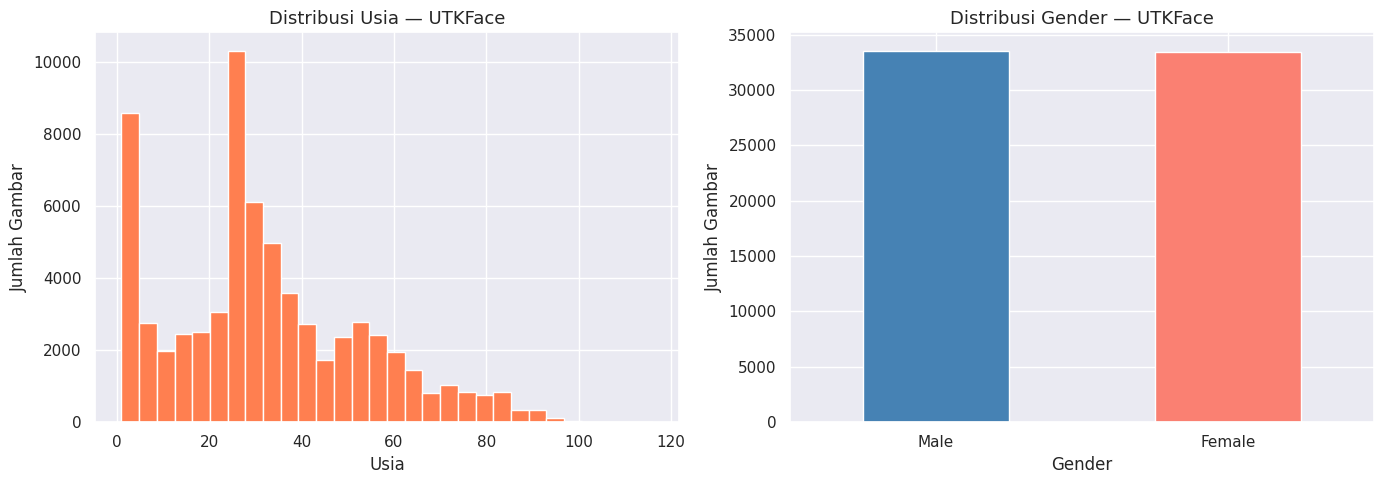

In [49]:
# Distribusi usia dan gender di UTKFace
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram usia
axes[0].hist(df_utk['age'], bins=30, color='coral', edgecolor='white')
axes[0].set_title('Distribusi Usia — UTKFace', fontsize=13)
axes[0].set_xlabel('Usia')
axes[0].set_ylabel('Jumlah Gambar')

# Distribusi gender
gender_map = {0: 'Male', 1: 'Female'}
df_utk['gender_label'] = df_utk['gender'].map(gender_map)
df_utk['gender_label'].value_counts().plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], edgecolor='white')
axes[1].set_title('Distribusi Gender — UTKFace', fontsize=13)
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Jumlah Gambar')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/reports/utk_age_gender_distribution.png', dpi=150)
plt.show()

In [50]:
# Cek ukuran gambar sampel dari UTKFace
sample_sizes = []
sample_paths = df_utk['filepath'].sample(min(200, len(df_utk)), random_state=42).tolist()

for path in sample_paths:
    try:
        img = Image.open(path)
        sample_sizes.append(img.size)  # (width, height)
    except:
        pass

df_sizes = pd.DataFrame(sample_sizes, columns=['width', 'height'])
print('Statistik ukuran gambar (sample 200 gambar):')
display(df_sizes.describe())
print(f'\nUkuran unik: {df_sizes.drop_duplicates().shape[0]} kombinasi berbeda')

Statistik ukuran gambar (sample 200 gambar):


,width,height
count,200.0,200.0
mean,200.0,200.0
std,0.0,0.0
min,200.0,200.0
25%,200.0,200.0
50%,200.0,200.0
75%,200.0,200.0
max,200.0,200.0



Ukuran unik: 1 kombinasi berbeda


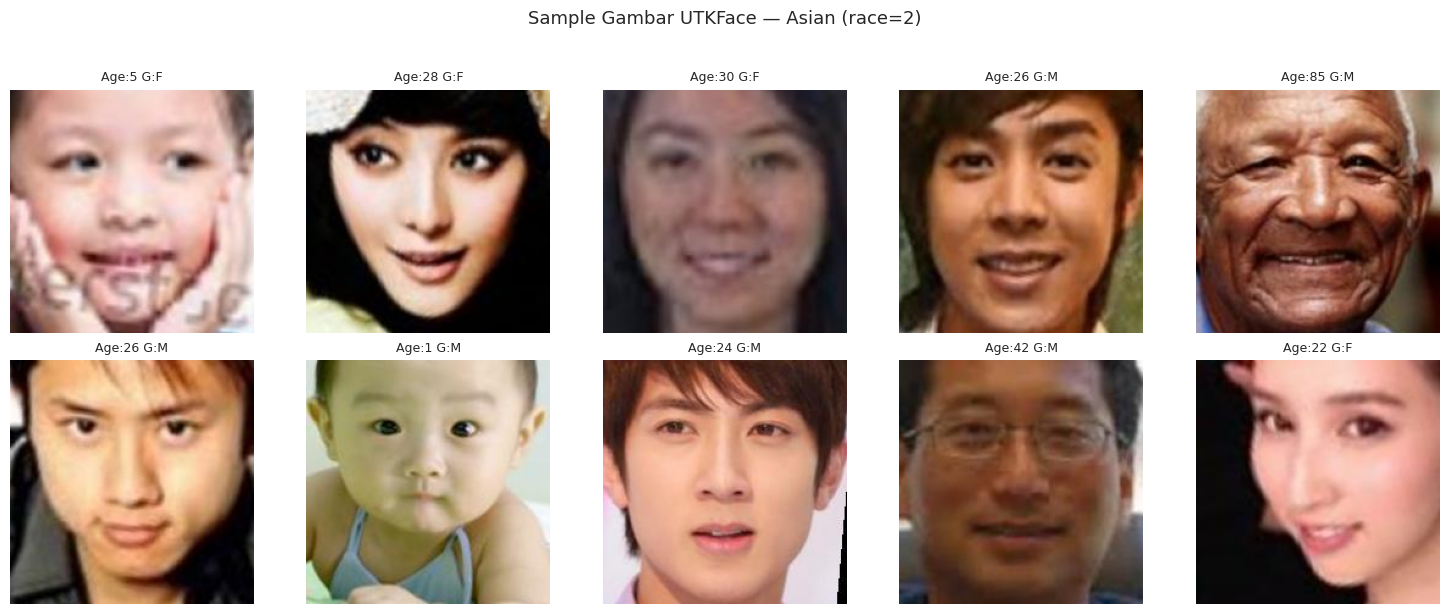


Total gambar Asian di UTKFace: 9974


In [51]:
# Tampilkan sampel gambar UTKFace (Asian)
df_utk_asian = df_utk[df_utk['race'] == 2]
sample_asian = df_utk_asian['filepath'].sample(10, random_state=42).tolist()

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, path in enumerate(sample_asian):
    img = mpimg.imread(path)
    axes[i].imshow(img)
    fname = Path(path).stem
    parts = fname.split('_')
    axes[i].set_title(f'Age:{parts[0]} G:{"M" if parts[1]=="0" else "F"}', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Sample Gambar UTKFace — Asian (race=2)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/reports/utk_asian_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nTotal gambar Asian di UTKFace: {len(df_utk_asian)}')

### 2.2 Assessing FairFace

In [52]:
# Tampilkan info CSV FairFace
print('Info DataFrame FairFace Label:')
print(df_fairface_label.info())
print('\nContoh data:')
display(df_fairface_label.head(10))
print('\nNilai unik kolom race:')
print(df_fairface_label['race'].value_counts())

Info DataFrame FairFace Label:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97698 entries, 0 to 97697
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   file          97698 non-null  object
 1   age           97698 non-null  object
 2   gender        97698 non-null  object
 3   race          97698 non-null  object
 4   service_test  97698 non-null  bool  
 5   split         97698 non-null  object
dtypes: bool(1), object(5)
memory usage: 3.8+ MB
None

Contoh data:


,file,age,gender,race,service_test,split
0,val/1.jpg,3-9,Male,East Asian,False,val
1,val/2.jpg,50-59,Female,East Asian,True,val
2,val/3.jpg,30-39,Male,White,True,val
3,val/4.jpg,20-29,Female,Latino_Hispanic,True,val
4,val/5.jpg,20-29,Male,Southeast Asian,False,val
5,val/6.jpg,30-39,Male,Latino_Hispanic,False,val
6,val/7.jpg,20-29,Male,Black,True,val
7,val/8.jpg,3-9,Male,East Asian,False,val
8,val/9.jpg,20-29,Male,Southeast Asian,False,val
9,val/10.jpg,3-9,Male,Southeast Asian,False,val



Nilai unik kolom race:
race
White              18612
Latino_Hispanic    14990
East Asian         13837
Indian             13835
Black              13789
Southeast Asian    12210
Middle Eastern     10425
Name: count, dtype: int64


Distribusi Ras di FairFace:
race
White              18612
Latino_Hispanic    14990
East Asian         13837
Indian             13835
Black              13789
Southeast Asian    12210
Middle Eastern     10425
Name: count, dtype: int64

Jumlah gambar East Asian + Southeast Asian: 26047


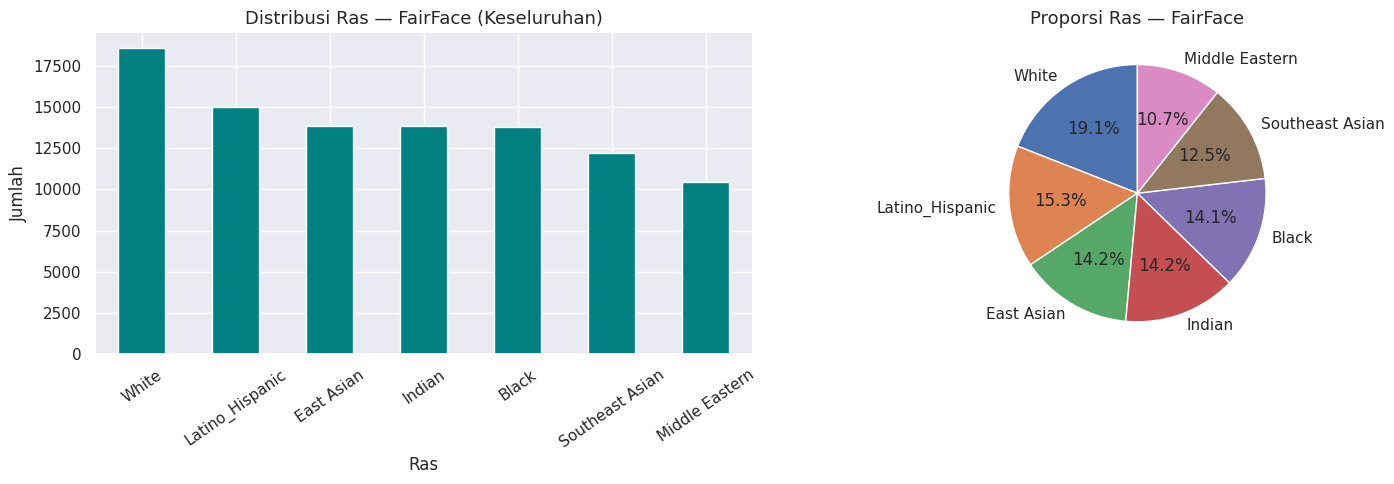

In [53]:
# Distribusi ras di FairFace
race_ff = df_fairface_label['race'].value_counts()
print('Distribusi Ras di FairFace:')
print(race_ff)

asian_races = ['East Asian', 'Southeast Asian']
df_ff_asian = df_fairface_label[df_fairface_label['race'].isin(asian_races)]
print(f'\nJumlah gambar East Asian + Southeast Asian: {len(df_ff_asian)}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

race_ff.plot(kind='bar', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Distribusi Ras — FairFace (Keseluruhan)', fontsize=13)
axes[0].set_xlabel('Ras')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=35)

race_ff.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporsi Ras — FairFace', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/reports/fairface_race_distribution.png', dpi=150)
plt.show()

In [54]:
# Cek apakah ada missing value di label FairFace
print('Missing values di FairFace CSV:')
print(df_fairface_label.isnull().sum())

print('\nDistribusi gender FairFace:')
print(df_fairface_label['gender'].value_counts())

print('\nDistribusi age FairFace:')
print(df_fairface_label['age'].value_counts())

Missing values di FairFace CSV:
file            0
age             0
gender          0
race            0
service_test    0
split           0
dtype: int64

Distribusi gender FairFace:
gender
Male      51778
Female    45920
Name: count, dtype: int64

Distribusi age FairFace:
age
20-29           28898
30-39           21580
40-49           12097
3-9             11764
10-19           10284
50-59            7024
60-69            3100
0-2              1991
more than 70      960
Name: count, dtype: int64


Kolom file/path yang ditemukan: ['file']


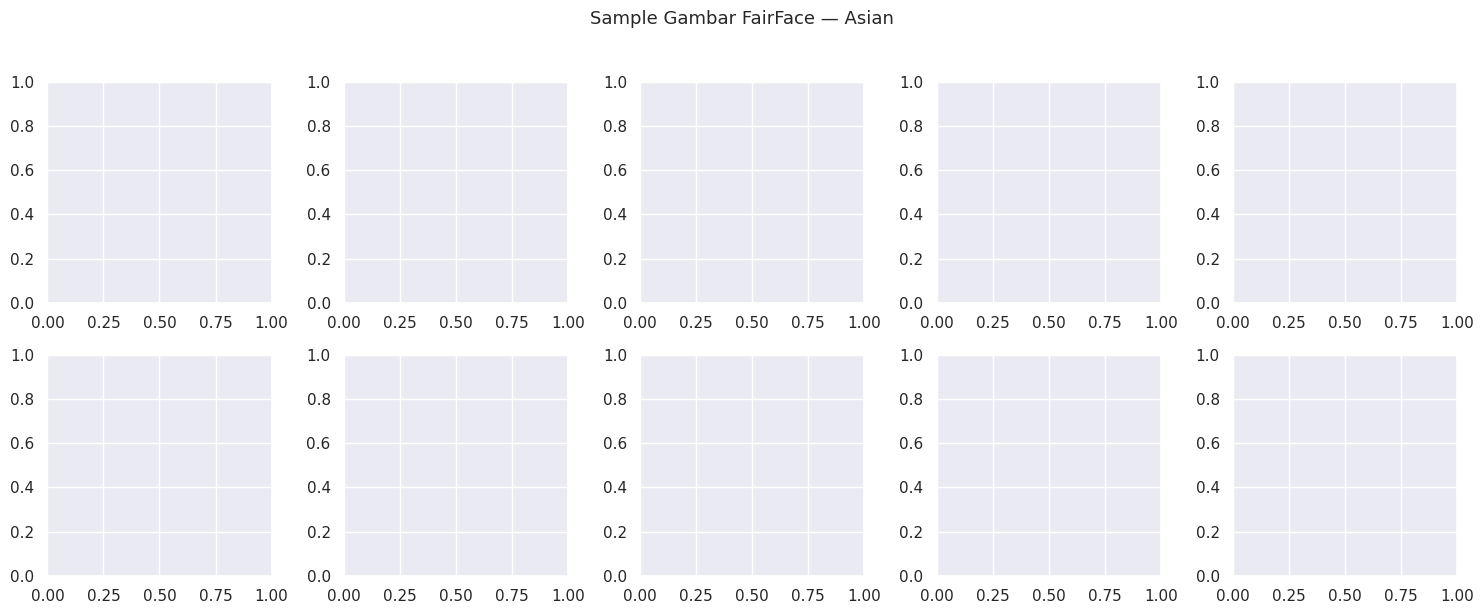

In [55]:
# Tampilkan sampel gambar FairFace Asian
file_col = [c for c in df_fairface_label.columns if 'file' in c.lower() or 'path' in c.lower() or 'image' in c.lower()]
print(f'Kolom file/path yang ditemukan: {file_col}')

if file_col:
    path_col = file_col[0]
    sample_ff_asian = df_ff_asian[path_col].sample(min(10, len(df_ff_asian)), random_state=42).tolist()

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()

    for i, fname in enumerate(sample_ff_asian):
        # Coba beberapa kemungkinan path
        possible_paths = [
            f"{BASE_DIR}/raw/fairface/{fname}",
            f"{BASE_DIR}/raw/fairface/train/{fname}",
            f"{BASE_DIR}/raw/fairface/val/{fname}",
        ]
        for p in possible_paths:
            if os.path.exists(p):
                img = mpimg.imread(p)
                axes[i].imshow(img)
                axes[i].set_title(df_ff_asian[df_ff_asian[path_col]==fname]['race'].values[0], fontsize=8)
                axes[i].axis('off')
                break

    plt.suptitle('Sample Gambar FairFace — Asian', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{BASE_DIR}/reports/fairface_asian_samples.png', dpi=150, bbox_inches='tight')
    plt.show()

### 2.3 Assessing Men Face Shape

In [56]:
# Scan struktur folder Men Face Shape
men_base = Path(f'{BASE_DIR}/raw/men_face_shape')
men_records = []

for img_path in men_base.rglob('*.jpg'):
    parts = img_path.parts
    # Ambil nama folder sebagai label face shape
    folder_name = img_path.parent.name
    split_type = None

    # Cek apakah termasuk training_set atau testing_set
    for part in parts:
        if 'train' in part.lower():
            split_type = 'train'
        elif 'test' in part.lower():
            split_type = 'test'

    men_records.append({
        'filepath': str(img_path),
        'filename': img_path.name,
        'face_shape': folder_name,
        'split': split_type
    })

df_men = pd.DataFrame(men_records)
print(f'Total file Men Face Shape: {len(df_men)}')
print(f'\nDistribusi face shape:')
print(df_men['face_shape'].value_counts())
print(f'\nDistribusi split (train/test):')
print(df_men['split'].value_counts())

Total file Men Face Shape: 1309

Distribusi face shape:
face_shape
ovale          346
round          340
square         318
rectangular    305
Name: count, dtype: int64

Distribusi split (train/test):
split
train    925
test     384
Name: count, dtype: int64


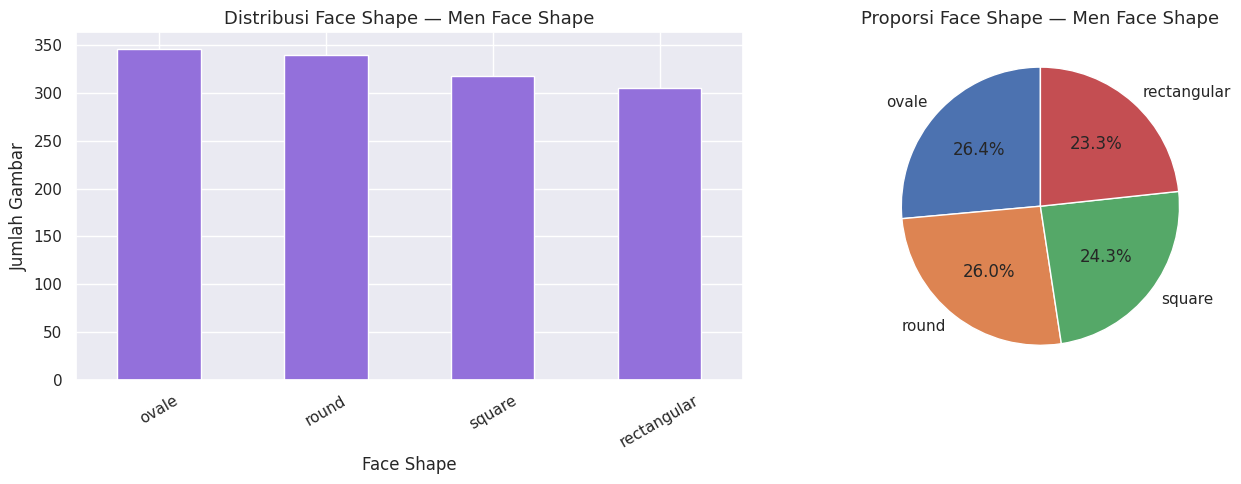

In [57]:
# Visualisasi distribusi face shape Men Face Shape
face_shape_counts = df_men['face_shape'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

face_shape_counts.plot(kind='bar', ax=axes[0], color='mediumpurple', edgecolor='white')
axes[0].set_title('Distribusi Face Shape — Men Face Shape', fontsize=13)
axes[0].set_xlabel('Face Shape')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].tick_params(axis='x', rotation=30)

face_shape_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporsi Face Shape — Men Face Shape', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/reports/men_faceshape_distribution.png', dpi=150)
plt.show()

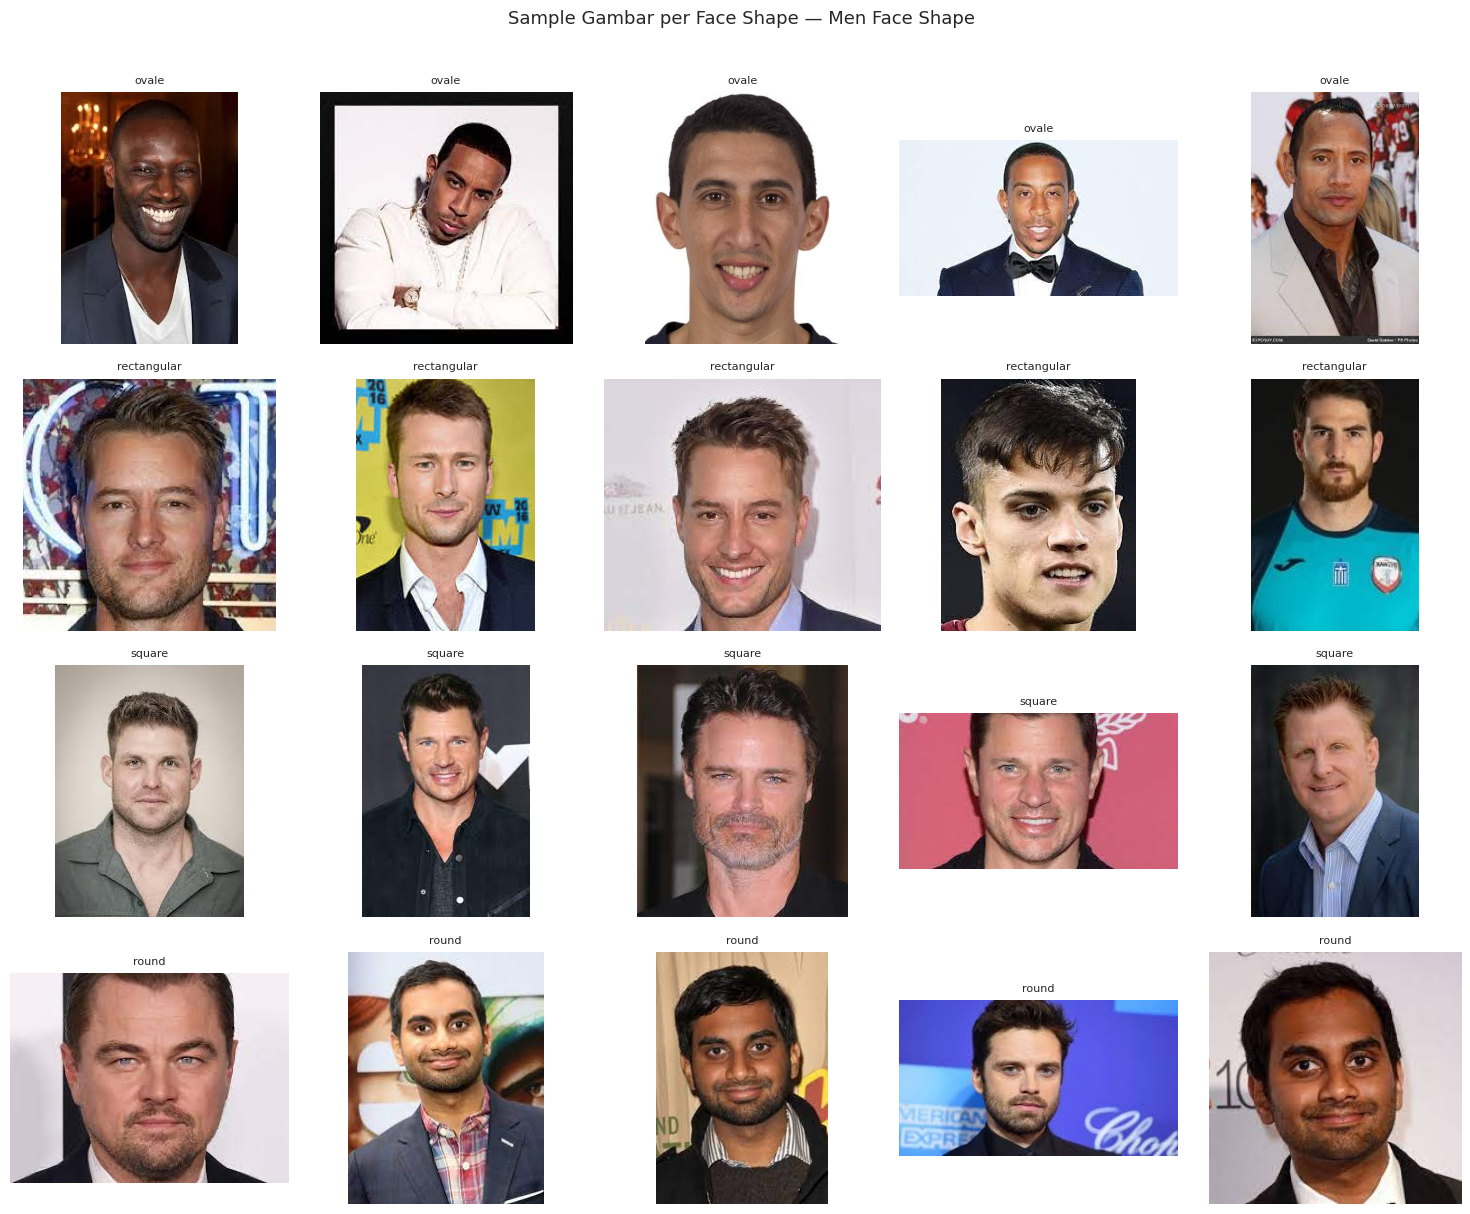

In [58]:
# Tampilkan sampel gambar per kategori Men Face Shape
face_shapes = df_men['face_shape'].unique()
n_shapes = len(face_shapes)

fig, axes = plt.subplots(n_shapes, 5, figsize=(15, n_shapes * 3))
if n_shapes == 1:
    axes = [axes]

for row_idx, shape in enumerate(face_shapes):
    samples = df_men[df_men['face_shape'] == shape]['filepath'].sample(
        min(5, len(df_men[df_men['face_shape'] == shape])), random_state=42
    ).tolist()

    for col_idx in range(5):
        ax = axes[row_idx][col_idx]
        if col_idx < len(samples):
            try:
                img = mpimg.imread(samples[col_idx])
                ax.imshow(img)
                ax.set_title(shape, fontsize=8)
            except:
                ax.set_title('Error', fontsize=8)
        ax.axis('off')

plt.suptitle('Sample Gambar per Face Shape — Men Face Shape', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/reports/men_faceshape_samples.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Ringkasan Hasil Assessing

Bagian ini merangkum temuan dari proses assessing sebagai dasar untuk cleaning di notebook berikutnya.

In [59]:
# Buat tabel ringkasan assessing
utk_asian_count = len(df_utk[df_utk['race'] == 2])
ff_asian_count  = len(df_ff_asian)
men_total       = len(df_men)

summary = pd.DataFrame({
    'Dataset': ['UTKFace', 'FairFace', 'Men Face Shape'],
    'Total Gambar (Raw)': [
        len(df_utk),
        len(df_fairface_label),
        men_total
    ],
    'Gambar Asian / Relevan': [
        utk_asian_count,
        ff_asian_count,
        men_total
    ],
    'Sudah Ada Label Face Shape': ['Tidak', 'Tidak', 'Ya'],
    'Format Label': [
        'Nama file (race=2)',
        'CSV terpisah (East/SE Asian)',
        'Nama folder'
    ],
    'Isu Utama yang Ditemukan': [
        'Watermark, crop tidak seragam, variasi pose & pencahayaan',
        'Label di CSV terpisah, perlu di-join, kualitas in-the-wild',
        'Dominan non-Asian, perlu filter & standarisasi ukuran'
    ]
})

print('='*80)
print('RINGKASAN HASIL ASSESSING DATA — FaceFit Barber DS Pipeline')
print('='*80)
display(summary)

# Simpan ke CSV
summary.to_csv(f'{BASE_DIR}/reports/assessing_summary.csv', index=False)
print('\nRingkasan disimpan ke reports/assessing_summary.csv')

RINGKASAN HASIL ASSESSING DATA — FaceFit Barber DS Pipeline


,Dataset,Total Gambar (Raw),Gambar Asian / Relevan,Sudah Ada Label Face Shape,Format Label,Isu Utama yang Ditemukan
0,UTKFace,66966,9974,Tidak,Nama file (race=2),"Watermark, crop tidak seragam, variasi pose & ..."
1,FairFace,97698,26047,Tidak,CSV terpisah (East/SE Asian),"Label di CSV terpisah, perlu di-join, kualitas..."
2,Men Face Shape,1309,1309,Ya,Nama folder,"Dominan non-Asian, perlu filter & standarisasi..."



Ringkasan disimpan ke reports/assessing_summary.csv


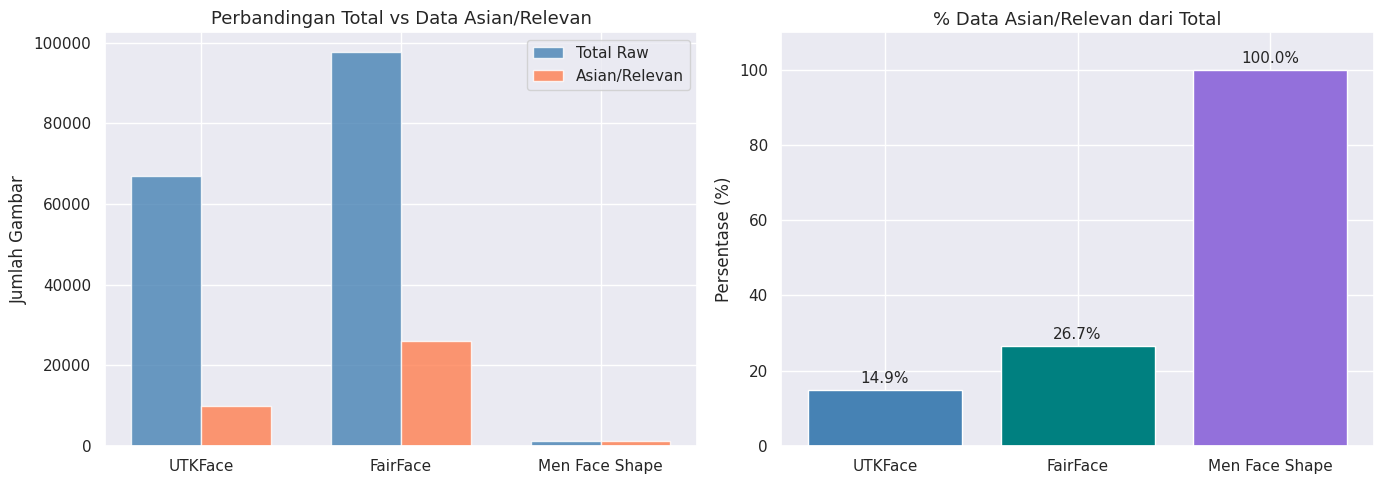

In [60]:
# Visualisasi perbandingan jumlah data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datasets    = ['UTKFace', 'FairFace', 'Men Face Shape']
total_raw   = [len(df_utk), len(df_fairface_label), men_total]
total_asian = [utk_asian_count, ff_asian_count, men_total]

x = range(len(datasets))
width = 0.35

axes[0].bar([i - width/2 for i in x], total_raw,   width, label='Total Raw',   color='steelblue',  alpha=0.8)
axes[0].bar([i + width/2 for i in x], total_asian, width, label='Asian/Relevan', color='coral', alpha=0.8)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(datasets)
axes[0].set_title('Perbandingan Total vs Data Asian/Relevan', fontsize=13)
axes[0].set_ylabel('Jumlah Gambar')
axes[0].legend()

# Persentase yang relevan
pct = [a/t*100 for a, t in zip(total_asian, total_raw)]
bars = axes[1].bar(datasets, pct, color=['steelblue', 'teal', 'mediumpurple'], edgecolor='white')
axes[1].set_title('% Data Asian/Relevan dari Total', fontsize=13)
axes[1].set_ylabel('Persentase (%)')
axes[1].set_ylim(0, 110)
for bar, p in zip(bars, pct):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{p:.1f}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/reports/dataset_comparison.png', dpi=150)
plt.show()

---
## 4. Kesimpulan & Rencana Cleaning

Berdasarkan hasil assessing di atas, berikut adalah temuan dan rencana tindakan untuk **Minggu 2 (Cleaning)**:

### Temuan Utama

| Dataset | Temuan |
|---|---|
| UTKFace | Variasi ukuran gambar tinggi, ada watermark, crop tidak seragam, beberapa gambar hanya sebagian wajah |
| FairFace | Label ada di CSV terpisah (berhasil di-join), kualitas in-the-wild, ada gambar gelap dan miring |
| Men Face Shape | Sudah berlabel per folder, dominan non-Asian, ukuran beragam |

### Rencana Cleaning (Notebook W2)

1. **UTKFace & FairFace**
   - Filter gambar Asian saja
   - Deteksi dan drop gambar blur (Laplacian variance < threshold)
   - Deteksi dan drop gambar corrupt (tidak bisa dibuka)
   - Crop wajah menggunakan face detector (OpenCV Haar Cascade / MediaPipe)
   - Resize ke ukuran standar (224x224)
   
2. **Men Face Shape**
   - Cleaning gambar non-Asian
   - Standarisasi ukuran (resize 224x224)
   - Cek duplikat

3. **Output akhir Cleaning**
   - Dataset wajah Asian yang bersih dan siap dilabeli face shape
   - Siap diteruskan ke tahap Geometric Labeling via MediaPipe

In [61]:
# Simpan dataframe untuk dipakai di notebook W2
df_utk.to_csv(f'{BASE_DIR}/reports/df_utkface_parsed.csv', index=False)
df_fairface_label.to_csv(f'{BASE_DIR}/reports/df_fairface_label.csv', index=False)
df_men.to_csv(f'{BASE_DIR}/reports/df_men_faceshape.csv', index=False)

print('✅ Semua dataframe disimpan:')
print(f'   - reports/df_utkface_parsed.csv     ({len(df_utk)} rows)')
print(f'   - reports/df_fairface_label.csv     ({len(df_fairface_label)} rows)')
print(f'   - reports/df_men_faceshape.csv      ({len(df_men)} rows)')
print('\nNotebook W1 selesai. Lanjut ke Notebook W2: Cleaning & Labeling')

✅ Semua dataframe disimpan:
   - reports/df_utkface_parsed.csv     (66966 rows)
   - reports/df_fairface_label.csv     (97698 rows)
   - reports/df_men_faceshape.csv      (1309 rows)

Notebook W1 selesai. Lanjut ke Notebook W2: Cleaning & Labeling


In [63]:
# download hasil filenya
from google.colab import files
import shutil

# khusus data report
# for f in glob.glob('/content/facefit_data/reports/*'):

# zip seluruh folder facefit_data (921 mb)
shutil.make_archive('/content/facefit_data_all', 'zip', '/content/facefit_data')

# download zip-nya
files.download('/content/facefit_data_all.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>